In [1]:
import numpy as np
import scipy as sp
import sympy as sm
import sys as sys
import matplotlib.pyplot as plt

In [2]:
# -*- coding: utf-8 -*-
"""
vib3D_owt_sysred
----------

Driver for vibration analysis of 3D OWT - system reduced model

Created: Feb 2026 - DTU Construct

# x = side-side (in-rotor plane)
# y = fore-aft (in wind direction)
# z = vertical (upwards , z = 0 at MSL)

# nodes  1 to 65: support structure = tower + monopile
#        66 to 69: drive-train
#        70 to 72: hub
#        73 to 141: blade 1 (vertical)
#        142 to 210: blade 2 (down + negative x, down-left from upstream view)
#        211 to 279: blade 3 (down + positive x, down-right from upstream view)

"""

# Import packages
import numpy as np
import scipy as sp
import sys as sys
import matplotlib.pyplot as plt

# if "module 'scipy' has no attribute 'linalg'" then import as:
from scipy import linalg as linalg
#sys.exit()

### INPUT - load X, K, M for 3D OWT FE model
# qn = [disp_x disp_y disp_z rot_x rot_y rot_z] in global {x,y,z}-coord sys.
npzfile = np.load('owt_XKM.npz')
X   = npzfile['X']
K   = npzfile['K']
M   = npzfile['M']

### SYSTEM REDUCTION - static condensation

modes_to_analyze = [2, 13]
step = 3

def part_nodes(start, end, step):
    nodes = list(np.arange(start, end+1, step))
    if nodes[-1] != end:
        nodes.append(end)
    if nodes[0] != start:
        nodes.insert(0, start)
    return np.array(nodes)

# Support = nodes 1–65 (as header states)
support = part_nodes(1, 45, 1)

drivetrain = part_nodes(66, 69, step)
hub = part_nodes(70, 72, step)
blade1 = part_nodes(73, 141, step)
blade2 = part_nodes(142, 210, step)
blade3 = part_nodes(211, 279, step)

nodes = np.unique(np.concatenate((
    support,
    drivetrain,
    hub,
    blade1,
    blade2,
    blade3
)))

# dynamic dofs in Id
block = np.arange(1,6+1)                        # [1, 2, 3, 4, 5, 6]
Id_matrix = (nodes[:, None] - 1) * 6 + block  # shape: (len(nodes_d), 6)
Id = Id_matrix.ravel()                          # flatten to 1D

# static dofs in Is
Is = np.arange(1,6*279+1,1) # all dofs
Is = np.setdiff1d(Is,Id)    # static = remove dynamic

# block matrices
Mdd = M[np.ix_(Id-1,Id-1)]
Mds = M[np.ix_(Id-1,Is-1)]
Msd = M[np.ix_(Is-1,Id-1)]
Mss = M[np.ix_(Is-1,Is-1)]

Kdd = K[np.ix_(Id-1,Id-1)]
Kds = K[np.ix_(Id-1,Is-1)]
Ksd = K[np.ix_(Is-1,Id-1)]
Kss = K[np.ix_(Is-1,Is-1)]

# static constraint matrix
S = -np.linalg.solve(Kss,Ksd)
ST = np.transpose(S)

# reduced matrices
K = Kdd + np.dot(ST,Ksd) + np.dot(Kds,S) + np.dot(ST, np.dot(Kss,S) )
M = Mdd + np.dot(ST,Msd) + np.dot(Mds,S) + np.dot(ST, np.dot(Mss,S) )

### VIBRATION ANALYSIS - solve EVP
n_modes = 20    # Determines lowest n_modes eig solutions
[lam,U] = sp.linalg.eigh(K, M, subset_by_index=[0, n_modes - 1])
lam = np.real(lam)
omega = np.sqrt(lam)
iw = np.argsort(omega)

# Natural freqiencies and mode shapes (normalized to max = 1)
omega = omega[iw]
freq  = omega/(2*np.pi)
U = U[:,iw]
U_norm = U / U[np.argmax(np.abs(U), axis=0), np.arange(0, n_modes)]
print(freq[1])
print(freq[12])

# Save results in .npz file
#np.savez('vibprop_sysred',Xd=Xd,K=K,M=M,U=U,omega=omega,freq=freq,S=S,Id=Id,Is=Is)




0.18563819613022012
1.4601963553638746


In [3]:
 # Connectivity vector for viscous damper (Exercise 9/11)
d = 8  # lever arm in meters

# Global DOFs (Hardcoded to match Equation 5 in the PDF)
dof_node26 = 152
print(f"DOF for node 26: {dof_node26}")
w = np.zeros((K.shape[0], 1))

w[dof_node26-1, 0] = 1

DOF for node 26: 152


In [4]:
print(6*26-4)

152


In [5]:
# 1. Setup mode 13 normalization (Original system)
u_13 = U_norm[:, 12]  # Mode 13
m_13 = u_13.T @ M @ u_13
u_13_norm = u_13 / np.sqrt(m_13)

# 2. Iterate through nodes 1 to 46 with a span of 4
d = 1
node_range = np.arange(1, 47)
modal_amplitudes = []

for start_node in node_range:
    node_a = start_node
    
    # Rotation DOFs (4th DOF per node)
    global_dof_a = 6 * (node_a - 1) + 2

    # Use the Id vector from your system reduction to find the index in K_red
    try:
        idx_a = np.where(Id == global_dof_a - 1)[0][0]

        # Create connectivity vector w for this position
        w_loop = np.zeros((K.shape[0], 1))
        w_loop[idx_a, 0] = d
        
        # Calculate modal amplitude (w.T @ u)
        # Using .item() to extract the scalar from the matrix multiplication
        u_modal = (w_loop.T @ u_13_norm).item()
        modal_amplitudes.append(np.abs(u_modal))
        
    except IndexError:
        # If a DOF is not in the reduced set (e.g., fixed base), skip or append 0
        modal_amplitudes.append(0.0)
print(modal_amplitudes)
# 3. Find the best location
modal_amplitudes = np.array(modal_amplitudes)
best_idx = np.argmax(modal_amplitudes)
print(f"Max Modal Amplitude: {modal_amplitudes[best_idx]:.10f}")

[np.float64(7.512081096880652e-07), np.float64(7.72007903815136e-07), np.float64(8.65018241196206e-07), np.float64(1.1344109068326766e-06), np.float64(1.4111736020331345e-06), np.float64(1.6364753442002596e-06), np.float64(2.005522833348691e-06), np.float64(2.3620126295850113e-06), np.float64(2.7307409589486126e-06), np.float64(3.0913107065487846e-06), np.float64(3.4395216135761533e-06), np.float64(3.7713823135011213e-06), np.float64(4.083136501632311e-06), np.float64(4.372131171212933e-06), np.float64(4.597871847181135e-06), np.float64(4.8120750899934636e-06), np.float64(4.823032826066421e-06), np.float64(4.833910470440236e-06), np.float64(5.037336428115588e-06), np.float64(5.211715038531544e-06), np.float64(5.356289796645962e-06), np.float64(5.470889633688624e-06), np.float64(5.555608491382007e-06), np.float64(5.6106516113275055e-06), np.float64(5.6364894918897355e-06), np.float64(5.6338059057040825e-06), np.float64(5.603407555422935e-06), np.float64(5.546274878205218e-06), np.float6

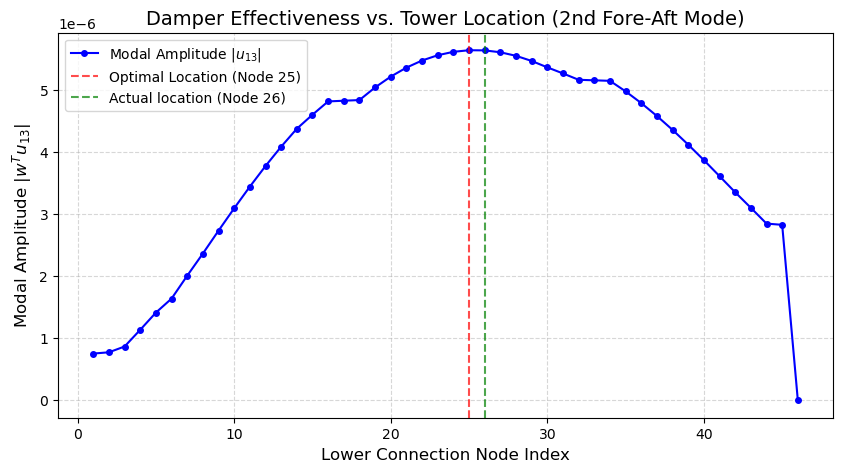

In [6]:
import matplotlib.pyplot as plt

# 1. (Ensure the loop from the previous step has run to populate 'modal_amplitudes')
# Convert list to array and take absolute value (as direction doesn't matter for energy)
amps_abs = np.abs(modal_amplitudes)

# 2. Plotting
plt.figure(figsize=(10, 5))
plt.plot(node_range[:len(amps_abs)], amps_abs, 'b-o', markersize=4, linewidth=1.5, label='Modal Amplitude $|u_{13}|$')

# Highlight the peak
best_node = node_range[np.argmax(amps_abs)]
plt.axvline(x=best_node, color='red', linestyle='--', alpha=0.7, 
            label=f'Optimal Location (Node {best_node})')

# Highlight the peak
best_node = node_range[np.argmax(amps_abs)]
plt.axvline(x=26, color='green', linestyle='--', alpha=0.7, 
            label=f'Actual location (Node 26)')

# Formatting
plt.title('Damper Effectiveness vs. Tower Location (2nd Fore-Aft Mode)', fontsize=14)
plt.xlabel('Lower Connection Node Index', fontsize=12)
plt.ylabel('Modal Amplitude $|w^T u_{13}|$', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()


In [7]:
u_13_modal_norm = u_13 / u_13[dof_node26-1]

m_13_modal_norm = np.dot(u_13_modal_norm.T, np.dot(M, u_13_modal_norm))
k_13_modal_norm = np.dot(u_13_modal_norm.T, np.dot(K, u_13_modal_norm))
print(m_13_modal_norm)
print(k_13_modal_norm)

606178.8065197308
51024999.4300349


In [8]:
zeta_des = 0.02

mu = sm.symbols('mu')

eq = sm.Eq(zeta_des, sm.sqrt(1/8 * mu/(1+mu)))

mu_sol = sm.solve(eq, mu)
print(f"Required damping ratio (mu) for 2% damping: {mu_sol[0]:.4f}")

m_TMD = mu_sol[0] * m_13_modal_norm
print(f"Required TMD mass (m_TMD): {m_TMD:.2f} kg")

Required damping ratio (mu) for 2% damping: 0.0032
Required TMD mass (m_TMD): 1946.00 kg


In [9]:
mu_val = float(mu_sol[0])  

k = k_13_modal_norm* mu_val/(1+mu_val)**2

print(k)

c = np.sqrt(k_13_modal_norm * m_13_modal_norm) * np.sqrt(2*mu_val**3/(1+mu_val)**3)

print(c)

162757.50218194793
1423.743793026606


In [10]:
omega_inf = omega[12]/(sm.sqrt(1+mu_sol[0])) 
print(f"Natural frequency of mode 13 with TMD: {omega_inf:.4f} rad/s")

Natural frequency of mode 13 with TMD: 9.1600 rad/s


In [11]:
zeta_d_val = zeta_des      # Your target damping ratio (0.02)

# 1. Structural Response (Equation 5.99)
# x0 / (f/k0) = (mu - 2*i*zeta_d*sqrt(1 + mu)) / mu
numerator_5_99 = mu_val - 2j * zeta_d_val * np.sqrt(1 + mu_val)
structural_response = numerator_5_99 / mu_val

# 2. Dynamic Amplification Squared (Equation 5.100)
# |x0 / (f/k0)|^2 = (mu^2 + (2*zeta_d)^2 * (1 + mu)) / mu^2
numerator_5_100 = mu_val**2 + (2 * zeta_d_val)**2 * (1 + mu_val)
denominator_5_100 = mu_val**2
dyn_amp_squared = numerator_5_100 / denominator_5_100

print(f"Structural Response (complex): {structural_response:.4f}")
print(f"Dynamic Amplification Squared: {dyn_amp_squared:.4f}")

# Verification: The squared magnitude of the complex response 
# should match the dynamic amplification result.
print(f"Verification (abs(resp)^2): {np.abs(structural_response)**2:.4f}")

Structural Response (complex): 1.0000-12.4800j
Dynamic Amplification Squared: 156.7500
Verification (abs(resp)^2): 156.7500


In [12]:
def calculate_optimal_damping(mu):
    """
    Calculates various damping ratios based on equations 5.101 and 5.102.
    """
    # Equation 5.101: Optimal damping ratio squared
    zeta_opt_sq = 0.5 * (mu / (1 + mu))
    zeta_opt = np.sqrt(zeta_opt_sq)
    
    # Equation 5.102: Classic Den Hartog/Brock value
    zeta_classic_sq = (3/8) * (mu / (1 + mu))
    zeta_classic = np.sqrt(zeta_classic_sq)
    
    # Equation for zeta_star (largest damping without changing nature)
    zeta_star = np.sqrt(mu / (1 + mu))
    
    return zeta_opt, zeta_classic, zeta_star

def calculate_relative_motion_amplification(mu):
    """
    Calculates the amplification factor of relative motion at omega_inf.
    Based on equation 5.104.
    """
    # Equation 5.104: |xd / (f/k0)| at omega_inf
    amp_factor = (1 + mu) / mu
    return amp_factor


In [13]:
z_opt, z_classic, z_star = calculate_optimal_damping(mu_val)
rel_amp = calculate_relative_motion_amplification(mu_val)

print(f"  Optimal damping (zeta_opt): {z_opt:.4f}")
print(f"  Classic damping (zeta_classic): {z_classic:.4f}")
print(f"  Limit damping (zeta_star): {z_star:.4f}")
print(f"  Rel. motion amplification factor: {rel_amp:.2f}")

# Verify the 12% difference claim (zeta_opt vs zeta_classic)
diff_pct = (z_opt / z_classic - 1) * 100
print(f"  Difference between opt and classic: {diff_pct:.1f}%")

  Optimal damping (zeta_opt): 0.0400
  Classic damping (zeta_classic): 0.0346
  Limit damping (zeta_star): 0.0566
  Rel. motion amplification factor: 312.50
  Difference between opt and classic: 15.5%


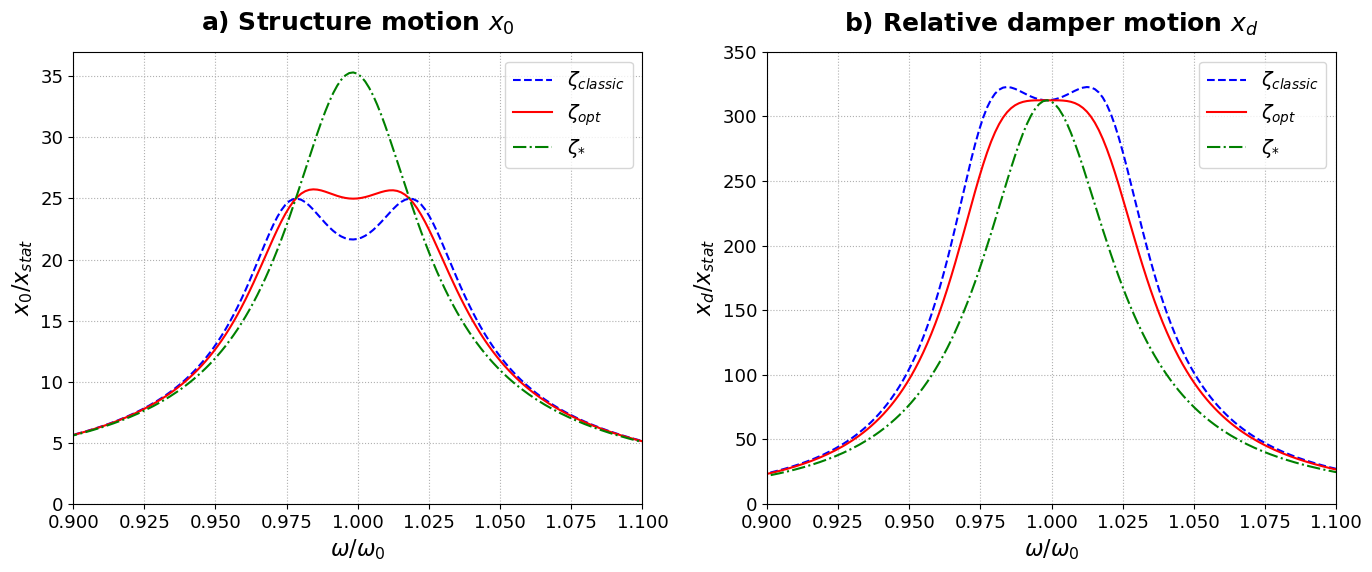

In [14]:
def get_amplification(w_ratio, mu, zeta, kappa):
    # Standard 2-DOF SDOF+TMD amplification formula
    # x0/xstat for a structure with a TMD
    num = np.sqrt((kappa**2 - w_ratio**2)**2 + (2 * zeta * w_ratio * kappa)**2)
    den = np.sqrt(((1 - w_ratio**2)*(kappa**2 - w_ratio**2) - mu * kappa**2 * w_ratio**2)**2 + 
                  (2 * zeta * w_ratio * kappa * (1 - w_ratio**2 * (1 + mu)))**2)
    return num / den

def get_relative_amplification(w_ratio, mu, zeta, kappa):
    # xd/xstat (relative motion)
    num = w_ratio**2
    den = np.sqrt(((1 - w_ratio**2)*(kappa**2 - w_ratio**2) - mu * kappa**2 * w_ratio**2)**2 + 
                  (2 * zeta * w_ratio * kappa * (1 - w_ratio**2 * (1 + mu)))**2)
    return num / den

# Parameters½   
mu = mu_val  # Mass ratio from your solve
kappa = 1.0 / (1 + mu)  # Optimal frequency tuning
w_ratios = np.linspace(0.6, 1.3, 500)

# Damping values from previous formulas
z_opt = np.sqrt(0.5 * (mu / (1 + mu)))
z_classic = np.sqrt((3/8) * (mu / (1 + mu)))
z_star = np.sqrt(mu / (1 + mu))

# Plot limits (you can adjust these values)
x_min, x_max = 0.9, 1.1
y_min_a, y_max_a = 0, 37  # For structure motion
y_min_b, y_max_b = 0, 350  # For relative damper motion

# Plotting

# Set a global font size base
plt.rcParams.update({'font.size': 16}) 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6)) # Slightly wider for better spacing

# Plot a) Structure Motion
ax1.plot(w_ratios, get_amplification(w_ratios, mu, z_classic, kappa), 'b--', label=r'$\zeta_{classic}$')
ax1.plot(w_ratios, get_amplification(w_ratios, mu, z_opt, kappa), 'r-', label=r'$\zeta_{opt}$')
ax1.plot(w_ratios, get_amplification(w_ratios, mu, z_star, kappa), 'g-.', label=r'$\zeta_{*}$')

ax1.set_title('a) Structure motion $x_0$', fontsize=18, fontweight='bold', pad=15)
ax1.set_xlabel(r'$\omega/\omega_0$', fontsize=16)
ax1.set_ylabel(r'$x_0/x_{stat}$', fontsize=16)
ax1.set_xlim([x_min, x_max])
ax1.set_ylim([y_min_a, y_max_a])
ax1.legend(fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=13)
ax1.grid(True, linestyle=':', alpha=1)

# Plot b) Relative Damper Motion
ax2.plot(w_ratios, get_relative_amplification(w_ratios, mu, z_classic, kappa), 'b--', label=r'$\zeta_{classic}$')
ax2.plot(w_ratios, get_relative_amplification(w_ratios, mu, z_opt, kappa), 'r-', label=r'$\zeta_{opt}$')
ax2.plot(w_ratios, get_relative_amplification(w_ratios, mu, z_star, kappa), 'g-.', label=r'$\zeta_{*}$')

ax2.set_title('b) Relative damper motion $x_d$', fontsize=18, fontweight='bold', pad=15)
ax2.set_xlabel(r'$\omega/\omega_0$', fontsize=16)
ax2.set_ylabel(r'$x_d/x_{stat}$', fontsize=16)
ax2.set_xlim([x_min, x_max])
ax2.set_ylim([y_min_b, y_max_b])
ax2.legend(fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=13)
ax2.grid(True, linestyle=':', alpha=1)

plt.tight_layout()
plt.show()

In [15]:
np.savez('sysred_TMD.npz', w=w, c=c, k=k, m_TMD=m_TMD, m_13_norm=m_13_modal_norm)